In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler,StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score,mean_absolute_error

In [6]:
import os
print(os.getcwd())
print(os.listdir())

c:\Users\Harshitha L\OneDrive\Desktop\house price
['app (1).py', 'app.py', 'house_price_tree_model.pkl', 'Regression_Model.ipynb', 'requirements.txt']


In [8]:
data = pd.read_csv(r"C:\Users\Harshitha L\Downloads\archive\House Price Prediction Dataset.csv")
data.head()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1,1360,5,4,3,1970,Downtown,Excellent,No,149919
1,2,4272,5,4,3,1958,Downtown,Excellent,No,424998
2,3,3592,2,2,3,1938,Downtown,Good,No,266746
3,4,966,4,2,2,1902,Suburban,Fair,Yes,244020
4,5,4926,1,4,2,1975,Downtown,Fair,Yes,636056


In [9]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   Id         2000 non-null   int64
 1   Area       2000 non-null   int64
 2   Bedrooms   2000 non-null   int64
 3   Bathrooms  2000 non-null   int64
 4   Floors     2000 non-null   int64
 5   YearBuilt  2000 non-null   int64
 6   Location   2000 non-null   str  
 7   Condition  2000 non-null   str  
 8   Garage     2000 non-null   str  
 9   Price      2000 non-null   int64
dtypes: int64(7), str(3)
memory usage: 156.4 KB


In [10]:
data.describe()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Price
count,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000
mean,1000.500000,2786.209500,3.003500,2.55250,1.993500,1961.446000,537676.855000
std,577.494589,1295.146799,1.424606,1.10899,0.809188,35.926695,276428.845719
min,1.000000,501.000000,1.000000,1.00000,1.000000,1900.000000,50005.000000
25%,500.750000,1653.000000,2.000000,2.00000,1.000000,1930.000000,300098.000000
50%,1000.500000,2833.000000,3.000000,3.00000,2.000000,1961.000000,539254.000000
75%,1500.250000,3887.500000,4.000000,4.00000,3.000000,1993.000000,780086.000000
max,2000.000000,4999.000000,5.000000,4.00000,3.000000,2023.000000,999656.000000


In [11]:
data.isnull().sum()

Id           0
Area         0
Bedrooms     0
Bathrooms    0
Floors       0
YearBuilt    0
Location     0
Condition    0
Garage       0
Price        0
dtype: int64

In [12]:
data.duplicated().sum()


np.int64(0)

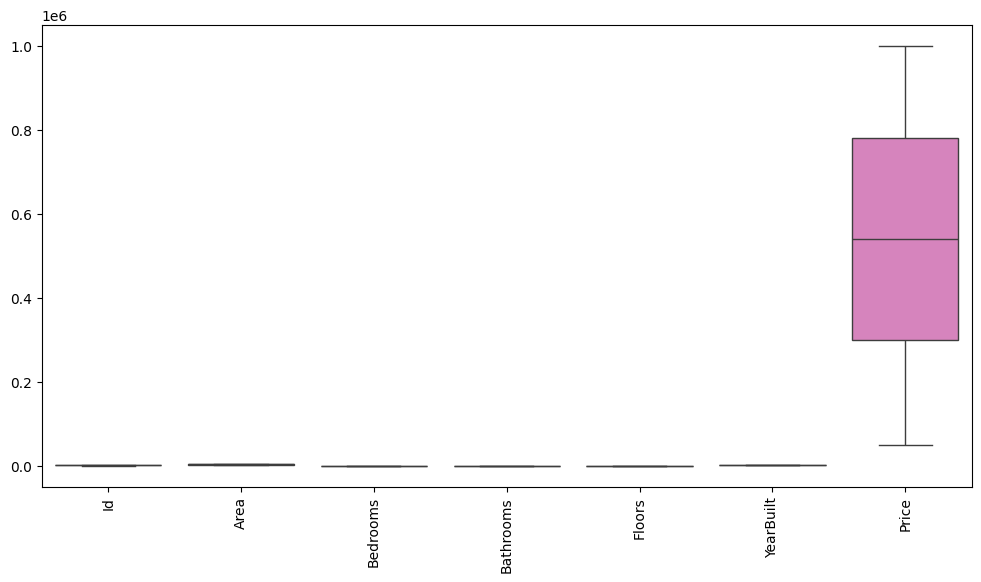

In [13]:
plt.figure(figsize=(12,6))
sns.boxplot(data=data)
plt.xticks(rotation=90)
plt.show()

Text(0.5, 1.0, 'Number of Bedrooms vs Price')

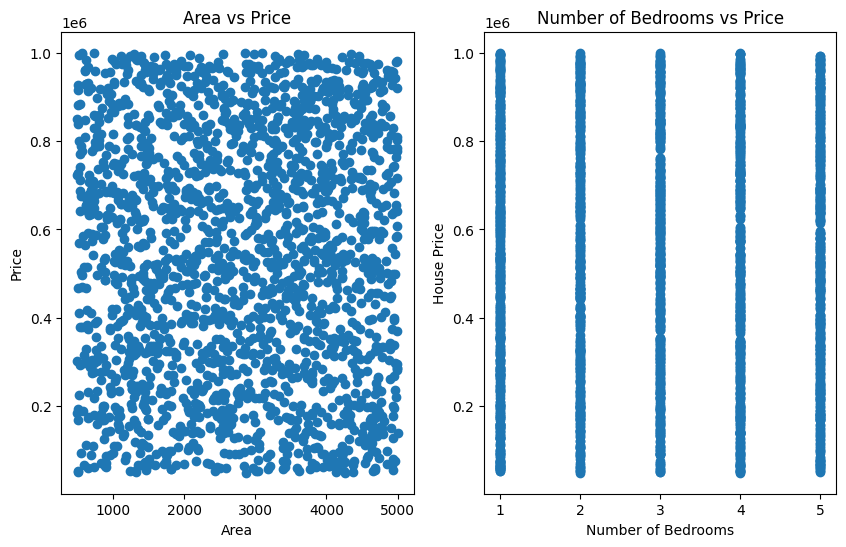

In [17]:
plt.figure(figsize=(10,6))
plt.subplot(1,2,1)
plt.scatter(data['Area'],data['Price'])
plt.xlabel('Area')
plt.ylabel('Price')
plt.title('Area vs Price')
plt.subplot(1,2,2)
plt.scatter(data['Bedrooms'],data['Price'])
plt.xlabel('Number of Bedrooms')
plt.ylabel('House Price')
plt.title('Number of Bedrooms vs Price')

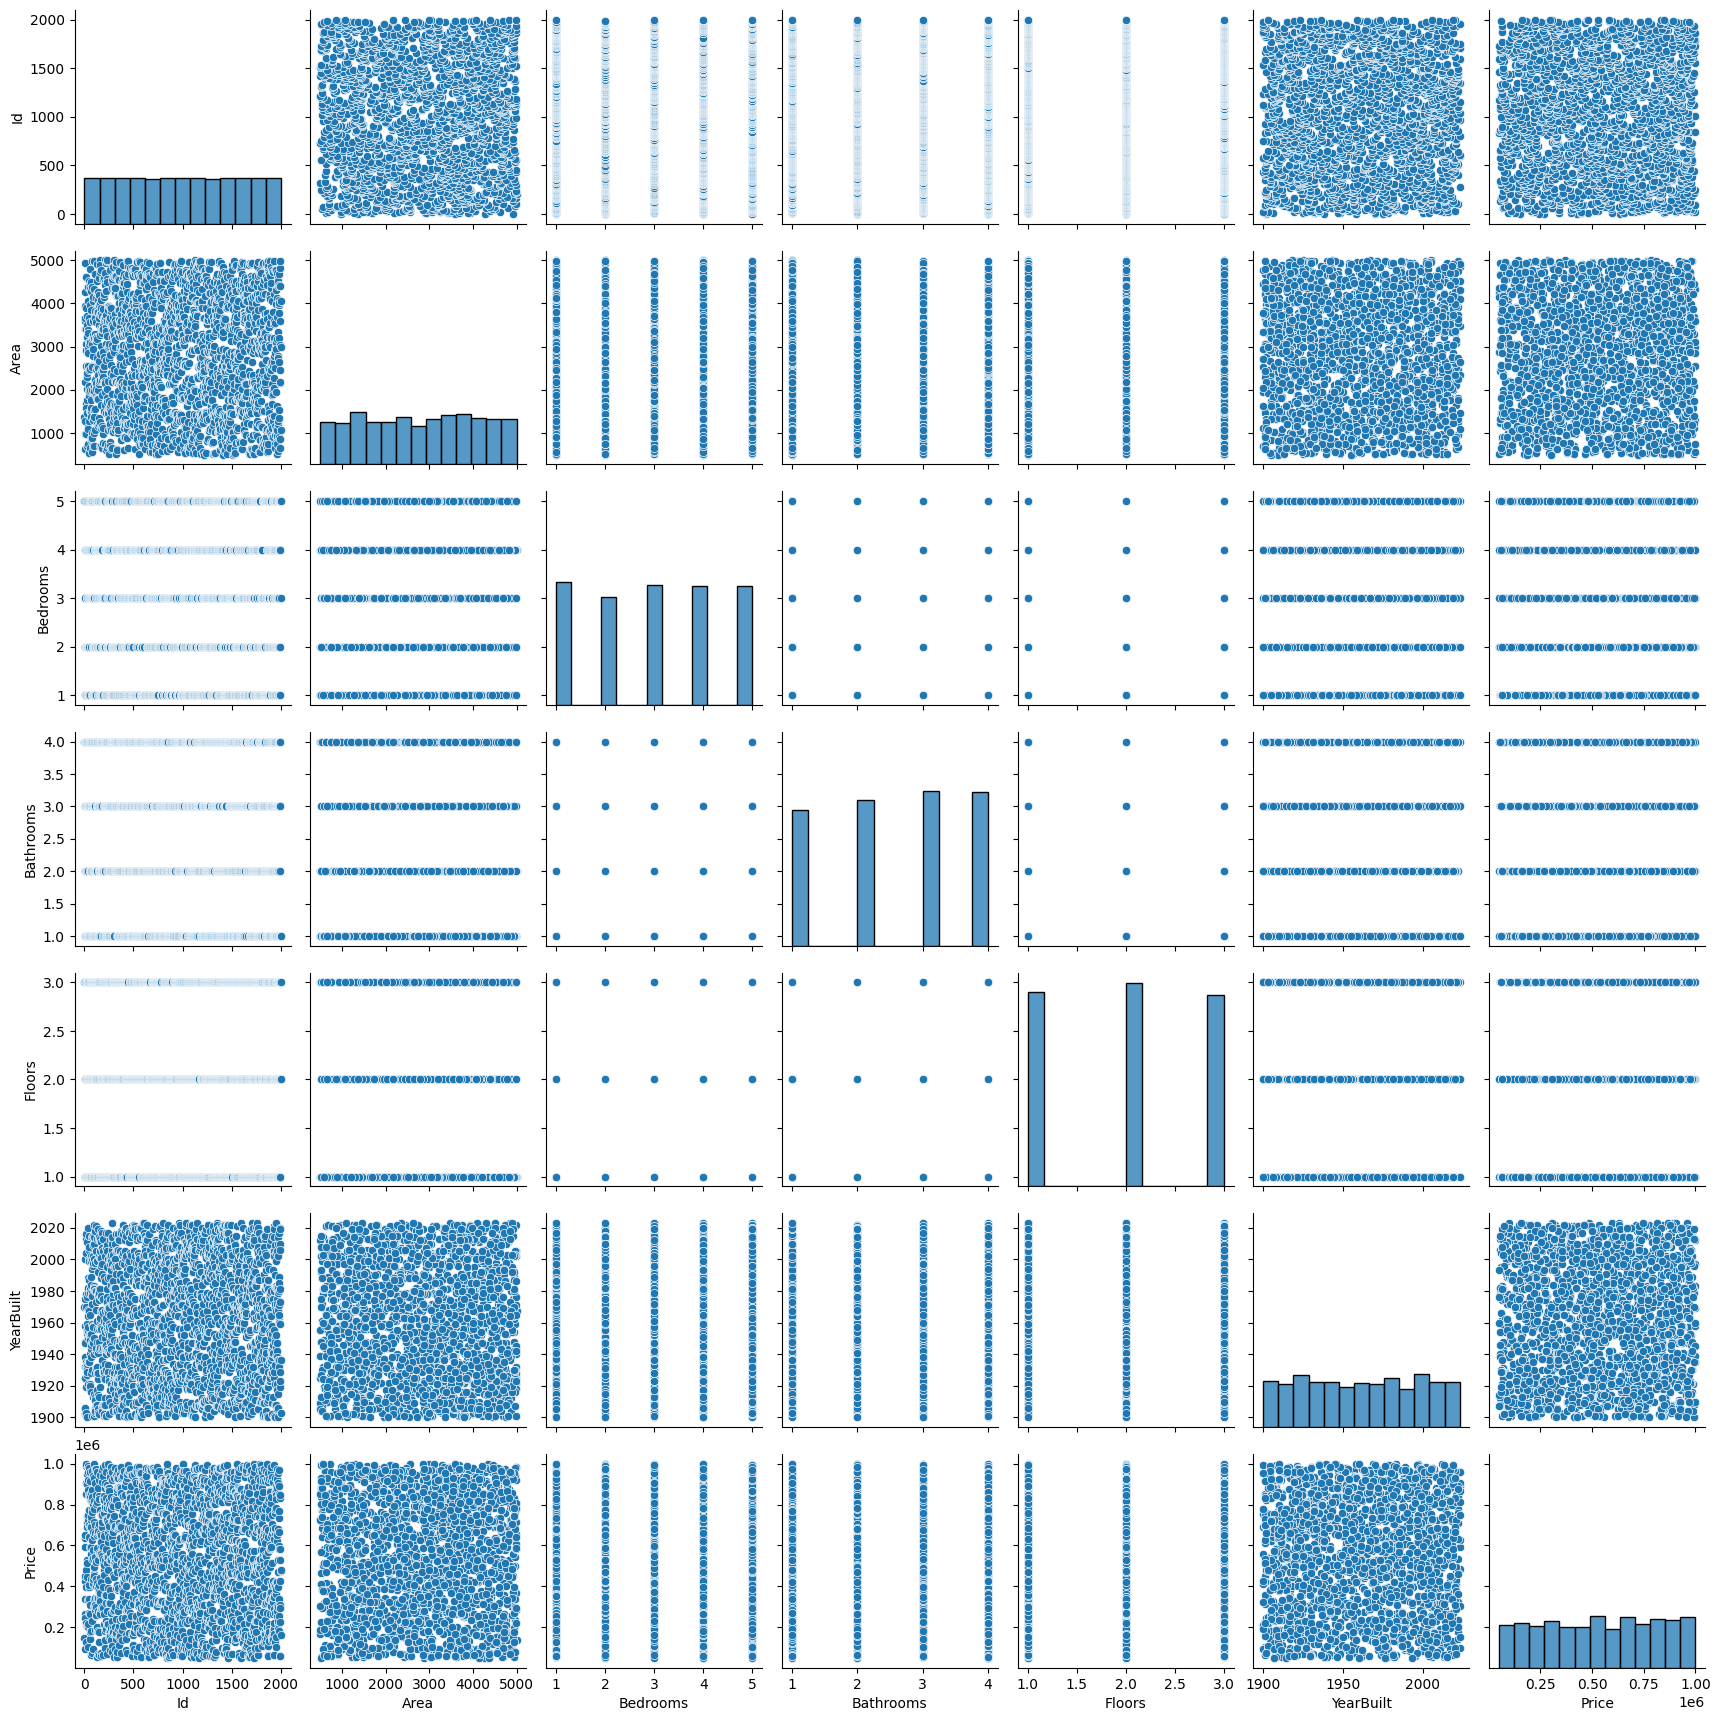

In [15]:
sns.pairplot(data)

In [23]:
print(data.dtypes)

Id           int64
Area         int64
Bedrooms     int64
Bathrooms    int64
Floors       int64
YearBuilt    int64
Location     int64
Condition    int64
Garage       int64
Price        int64
dtype: object


In [21]:
print(data["Location"].unique())
print(data["Condition"].unique())
print(data["Garage"].unique())

<StringArray>
['Downtown', 'Suburban', 'Urban', 'Rural']
Length: 4, dtype: str
<StringArray>
['Excellent', 'Good', 'Fair', 'Poor']
Length: 4, dtype: str
<StringArray>
['No', 'Yes']
Length: 2, dtype: str


In [22]:
from sklearn.preprocessing import LabelEncoder

le_location = LabelEncoder()
le_condition = LabelEncoder()
le_garage = LabelEncoder()

data["Location"] = le_location.fit_transform(data["Location"])

data["Condition"] = le_condition.fit_transform(data["Condition"])

data["Garage"] = le_garage.fit_transform(data["Garage"])

<Axes: >

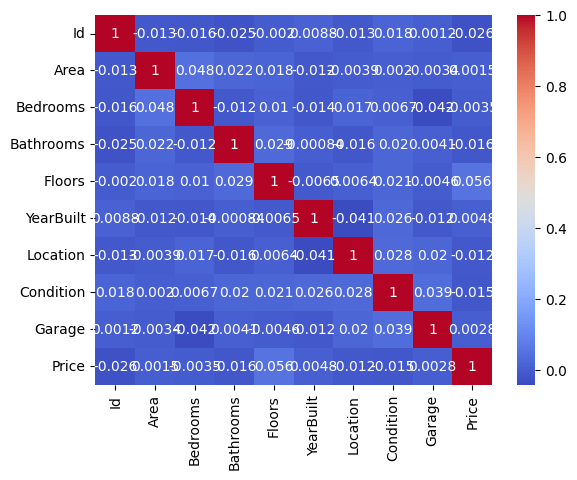

In [24]:
sns.heatmap(data.corr(), annot=True, cmap='coolwarm')

In [ ]:
# scaler = MinMaxScaler()
# data['Price'] = scaler.fit_transform(data[['House_Price']])


In [37]:
# scaler2 = StandardScaler()
# data['Square_Footage'] = scaler2.fit_transform(data[['Square_Footage']])
# data['Square_Footage'].min(), data['Square_Footage'].max()

In [44]:
x = data.drop(['Id','Price'],axis=1)
y = data['Price']

In [45]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [46]:
linear_model = LinearRegression()
linear_model.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [47]:
y_pred = linear_model.predict(x_test)
y_pred

array([510844.55800609, 539418.87521843, 502542.9891788 , 560243.21537465,
       573676.09846645, 547450.38288388, 547911.36773467, 546992.57655005,
       562122.64093663, 568418.93231839, 543981.04201363, 568581.48917716,
       494180.93154274, 534369.80109663, 518672.2980485 , 533128.46015755,
       555154.11364786, 553804.89986875, 558980.34324236, 511668.88047104,
       539869.84134873, 530844.60400111, 527257.5665389 , 571513.68736262,
       555171.48683593, 532879.07240733, 515804.34515504, 517839.89088436,
       532023.74891802, 500256.21730707, 494862.38773326, 548059.5947312 ,
       542507.97281599, 570397.41193111, 524177.85942732, 488534.72921744,
       567201.35623307, 583701.76224155, 515786.43837086, 507811.07698988,
       499911.86352156, 521901.32428546, 521299.52562298, 538833.24606057,
       546811.39914863, 543351.32301536, 560351.23630284, 523613.18865934,
       551798.1481872 , 541335.07913986, 499705.44623932, 531759.01289588,
       561999.12398141, 5

In [48]:
MAE = mean_absolute_error(y_test,y_pred)
MSE = mean_squared_error(y_test,y_pred)
RMSE = np.sqrt(MSE)
R2 = r2_score(y_test,y_pred)
print(f"Mean Absolute Error: {MAE}")
print(f"Mean Squared Error: {MSE}")
print(f"Root Mean Squared Error: {RMSE}")
print(f"R-squared: {R2}")

Mean Absolute Error: 244419.99901363705
Mean Squared Error: 78729422262.6482
Root Mean Squared Error: 280587.6374016649
R-squared: -0.011961539273188215


In [49]:
linear_model.coef_, linear_model.intercept_


(array([-3.84679917e-01,  1.32914377e+02, -9.93804686e+03,  2.36609202e+04,
         1.12689462e+02, -2.58109948e+03, -2.57769020e+03,  3.85995776e+03]),
 np.float64(299483.8142546364))

In [51]:
y_test_pred = linear_model.predict([[1500,3,2,1,2018,2,1,1]])
y_test_pred

C:\Users\Harshitha L\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([526617.76712865])

In [52]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

In [53]:
forest=RandomForestRegressor(random_state=42)

In [54]:
tree_model = DecisionTreeRegressor(random_state=42)
tree_model.fit(x_train,y_train)
forest.fit(x_train,y_train)
tree_pred = tree_model.predict(x_test)


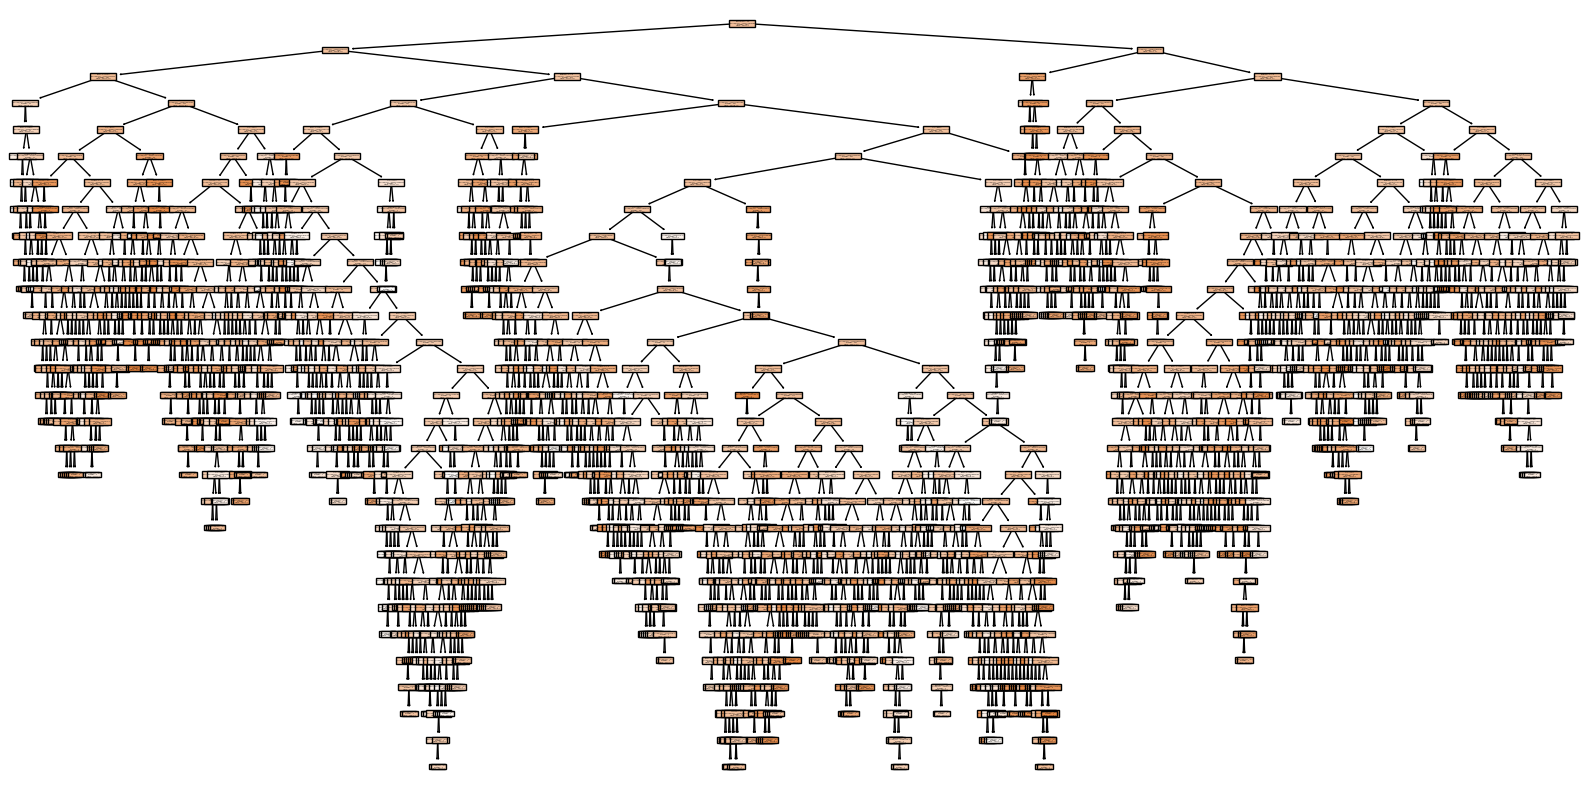

In [55]:
from sklearn.tree import plot_tree
tree_model.fit(x_train,y_train)
plt.figure(figsize=(20,10))
plot_tree(tree_model, feature_names=data.drop('Price',axis=1).columns, filled=True)
plt.show()

In [56]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

In [57]:
models={
    "Linear Regression":tree_model,
    "Decision Tree":tree_model,
    "Random Forest":forest
}

for name,model in models.items():

    pred=model.predict(x_test)

    print(name)

    print("MAE:",mean_absolute_error(y_test,pred))

    print("RMSE:",np.sqrt(mean_squared_error(y_test,pred)))

    print("R2:",r2_score(y_test,pred))

    print()

Linear Regression
MAE: 337135.3325
RMSE: 411324.0053244613
R2: -1.1746784697777648

Decision Tree
MAE: 337135.3325
RMSE: 411324.0053244613
R2: -1.1746784697777648

Random Forest
MAE: 253932.662325
RMSE: 293525.4663625025
R2: -0.10743569077376658



In [58]:
import joblib
joblib.dump(tree_model, "house_price_tree_model.pkl")

['house_price_tree_model.pkl']